In [1]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent


In [2]:
import numpy as np
import qutip

def truncate(qobj: qutip.Qobj, dimension: int) -> qutip.Qobj:
    if qobj.shape[1] == 1:  # is ket
        return qutip.Qobj(qobj.full()[:dimension, :])
    else:  # is operator or density matrix
        return qutip.Qobj(qobj.full()[:dimension, :dimension])



qubit 1-2 transition 0.3312803720997479
differential_stark_on_qubit_12_from_osc01  0.04488376951111395
differential_stark_on_qubit_12_from_osc12  0.04220368337273683
qubit_zero_lamb_on_osc01_12  0.0003087852448633299
qubit_zero_lamb_on_osc01_23  0.0006479275847510735
qubit_zero_lamb_on_osc01_34  0.0010123944728519518
qubit_zero_lamb_on_osc01_45  0.001398006905574789
qubit_zero_lamb_on_osc01_56  0.0018012872064545604
qubit_zero_lamb_on_osc01_67  0.00221933356365156
qubit_zero_lamb_on_osc01_78  0.002649716749608899
qubit_zero_lamb_on_osc01_89  0.0030903950973382166
qubit_zero_lamb_on_osc01_90  0.003539644248995444
detunning 01 0.024108232661372853
detunning 02 0.020775536849741982


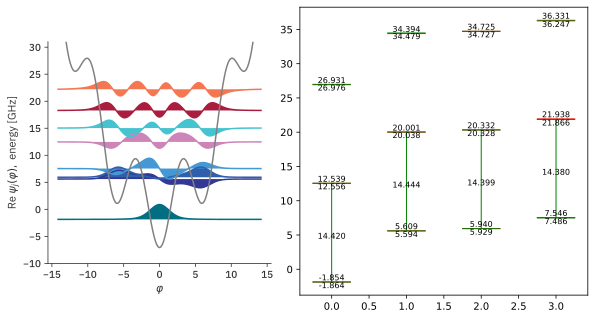

In [7]:
# g_strength = 0.7
# EJ = 11.076923
# EC = 1.78
# EL = 0.4
# E_osc = 14.012658

g_strength = 1
EJ = 7.0769230769
EC = 2.25
EL = 0.44
E_osc = 14.392405063


qubit_level = 20
osc_level = 15
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)

print(f"qubit 1-2 transition {qbt.eigenvals()[2]-qbt.eigenvals()[1]}")
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())

energies=  hilbertspace.eigenvals(qubit_level*osc_level)
def stark(ql1,ql2,ol):
    return abs(energies[product_to_dressed[(ql2,ol)]]-energies[product_to_dressed[(ql1,ol)]])
def lamb(ol1,ol2,ql):
    return abs(energies[product_to_dressed[(ql,ol2)]]-energies[product_to_dressed[(ql,ol1)]])
def detuning(ql1,ql2):
    return abs((energies[product_to_dressed[(ql1,1)]]-energies[product_to_dressed[(ql1,0)]])  -
                    (energies[product_to_dressed[(ql2,1)]]-energies[product_to_dressed[(ql2,0)]]))
    
differential_stark_on_qubit_12_from_osc01 = abs(stark(1,2,0)-stark(1,2,1)) # For reducing differential phase on off-diagonal elements of the qubit
differential_stark_on_qubit_12_from_osc12 = abs(stark(1,2,1)-stark(1,2,2))
qubit_zero_lamb_on_osc01_12 = abs(lamb(0,1,0)-lamb(1,2,0)) # For easy populating photons
qubit_zero_lamb_on_osc01_23 = abs(lamb(0,1,0)-lamb(2,3,0))
detunning_qubit01 = detuning(0,1) + detuning(0, 2)

print(f"differential_stark_on_qubit_12_from_osc01  {differential_stark_on_qubit_12_from_osc01}")
print(f"differential_stark_on_qubit_12_from_osc12  {differential_stark_on_qubit_12_from_osc12}")
print(f"qubit_zero_lamb_on_osc01_12  {abs(lamb(0,1,0)-lamb(1,2,0))}")
print(f"qubit_zero_lamb_on_osc01_23  {abs(lamb(0,1,0)-lamb(2,3,0))}")
print(f"qubit_zero_lamb_on_osc01_34  {abs(lamb(0,1,0)-lamb(3,4,0))}")
print(f"qubit_zero_lamb_on_osc01_45  {abs(lamb(0,1,0)-lamb(4,5,0))}")
print(f"qubit_zero_lamb_on_osc01_56  {abs(lamb(0,1,0)-lamb(5,6,0))}")
print(f"qubit_zero_lamb_on_osc01_67  {abs(lamb(0,1,0)-lamb(6,7,0))}")
print(f"qubit_zero_lamb_on_osc01_78  {abs(lamb(0,1,0)-lamb(7,8,0))}")
print(f"qubit_zero_lamb_on_osc01_89  {abs(lamb(0,1,0)-lamb(8,9,0))}")
print(f"qubit_zero_lamb_on_osc01_90  {abs(lamb(0,1,0)-lamb(9,10,0))}")
print(f"detunning 01 {detuning(0,1) }")
print(f"detunning 02 {detuning(0,2) }")
plot_specturum(qbt, osc, hilbertspace)

In [8]:
truncated_dim = 20

a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
a_trunc = truncate(a,truncated_dim)
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])
diag_dressed_hamiltonian = truncate(diag_dressed_hamiltonian,truncated_dim)



leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )


tot_time = 500
tlist = np.linspace(0, tot_time, tot_time*2)

amp = 0.002


kappa = 0.01
decay_term = np.sqrt(kappa) * a_trunc


In [9]:




with open('temp_functions.py', 'w') as f:
    f.write(f"""
from utils import *
            
w_d = {w_d}
amp = {amp}
def square_cos(t, *args):
    cos = np.cos(w_d * 2 * np.pi * t)
    return 2 * np.pi * amp * cos

    
def pad_back(qobj: qutip.Qobj, full_dimension: int) -> qutip.Qobj:
    if qobj.shape[1] == 1:  # is ket
        truncated_dim = qobj.shape[0]
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[:truncated_dim, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        truncated_dim = qobj.shape[0]
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[:truncated_dim, :truncated_dim] = qobj.full()
        return qutip.Qobj(padded_matrix)

def mesolve_and_pad(rho0,
            H_with_drive,
             tlist, 
            full_dim,
            c_ops = None
            ):

            
    temp = qutip.mesolve(
        H=H_with_drive,
        rho0=rho0,
        tlist=tlist,
        c_ops=c_ops,
        options=qutip.Options(store_states=True, nsteps=2000, num_cpus=1),
        progress_bar = True
    )
    padded_states = [pad_back(state, full_dim) for state in temp.states]
    return CustomOdeResult(times=temp.times, states=padded_states)
""")

from temp_functions import mesolve_and_pad, square_cos
H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos]]

results = [None] * 4
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(mesolve_and_pad, 
                               rho0=truncate(qutip.basis(hilbertspace.dimension, product_to_dressed[(i, 0)]), truncated_dim), 
                               H_with_drive=H_with_drive,
                               tlist=tlist, 
                               full_dim=hilbertspace.dimension,
                               c_ops = [decay_term],  
                               ): i for i in range(4)}
    
    for future in concurrent.futures.as_completed(futures):
        original_index = futures[future]
        results[original_index] = future.result()

os.remove('temp_functions.py')


10.0%. Run time:  12.25s. Est. time left: 00:00:01:50
10.0%. Run time:  12.47s. Est. time left: 00:00:01:52
10.0%. Run time:  13.46s. Est. time left: 00:00:02:01
10.0%. Run time:  20.43s. Est. time left: 00:00:03:03
20.0%. Run time:  26.17s. Est. time left: 00:00:01:44
20.0%. Run time:  26.83s. Est. time left: 00:00:01:47
20.0%. Run time:  40.08s. Est. time left: 00:00:02:40
20.0%. Run time:  41.97s. Est. time left: 00:00:02:47
30.0%. Run time:  43.04s. Est. time left: 00:00:01:40
30.0%. Run time:  46.24s. Est. time left: 00:00:01:47
40.0%. Run time:  63.12s. Est. time left: 00:00:01:34
30.0%. Run time:  63.53s. Est. time left: 00:00:02:28
40.0%. Run time:  65.68s. Est. time left: 00:00:01:38
30.0%. Run time:  73.15s. Est. time left: 00:00:02:50
50.0%. Run time:  83.25s. Est. time left: 00:00:01:23
40.0%. Run time:  85.14s. Est. time left: 00:00:02:07
50.0%. Run time:  85.15s. Est. time left: 00:00:01:25
60.0%. Run time: 103.31s. Est. time left: 00:00:01:08
60.0%. Run time: 104.53s. Es

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

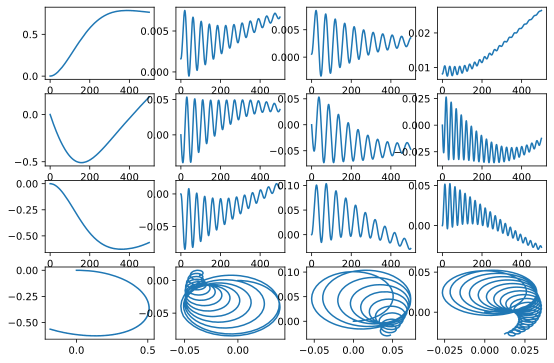

In [10]:

plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True,fix_ylim=False,plot_only_pn_alpha= True)

In [22]:
interactive_heatmap(results[0], product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=1999), Output…

In [11]:
def compute_contrast(results, res_idx1,res_idx2,# Which two results to compute contrast between
                     coeff, # in GHz
                     a,w_d,tlist,
                     fourier):
    
    # Step-1 compute expectation of alpha and put it in result.expect
    a_op = jnp.array(a.full())

    vectorized_compute_expectation = get_vectorized_compute_expectation_function()

    alphas = []
    for i in [res_idx1,res_idx2]:
        if hasattr(results[i], 'y'):
            states = jnp.array(results[i].y)  # assuming y contains JAX arrays or density matrices (obtained from qiskit solver)
        elif hasattr(results[i], 'states'):
            states = jnp.stack([jnp.array(q.full()) for q in results[i].states])  # assuming states contains QObj or density matrices (obtained from qutip-like solver)
        
        alpha_expect = vectorized_compute_expectation(states, a_op)
        alphas.append(alpha_expect)

    if fourier == True:
        first_dominant_freq =find_dominant_frequency(alphas[0],tlist)
    else:
        first_dominant_freq = w_d

    alphas[0] = alphas[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alphas[1] = alphas[1]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


    # Step-2 do integration
    squared_diff = np.square(abs(alphas[0]-alphas[1]))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*coeff*squared_diff[i]
                         )
    # Step-3 Plot
    plt.figure()
    plt.plot(tlist, integrals, label='Integral')
    plt.plot(tlist, squared_diff, label='Squared Difference')
    plt.yscale('log')
    plt.yticks([0.1,1, 2, 3, 4, 5, 6, 7, 8, 9, 10,100])
    plt.legend()
    plt.grid()
    plt.show()


# From the photon counting statistics paper, the coefficient should be kappa squared. I plotted contrast of both kappa and kappa squared.

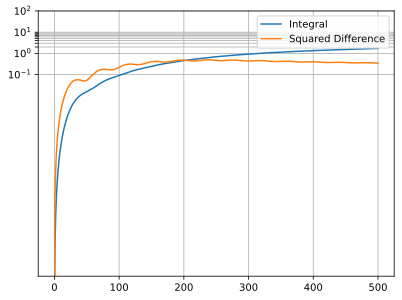

In [12]:
compute_contrast(results = results, 
                 res_idx1= 0, 
                 res_idx2 = 1,
                coeff = kappa,
                a = a,w_d = w_d,tlist = results[0].times,
                fourier = True)

In [5]:
t_stop = 215




tot_time = 230
tlist = np.linspace(0, tot_time, tot_time)[::4]


state_0_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed  +  state_1_dressed).unit()
state_minus_dressed = (state_0_dressed - state_1_dressed).unit()
initial_states  = [state_0_dressed,state_1_dressed,state_plus_dressed,state_minus_dressed ]

kappa = 0.01
decay_term = np.sqrt(kappa)*a

with open('temp_functions.py', 'w') as f:
    f.write(f"""
from utils import *
            
w_d = {w_d}
amp = {amp}
t_stop = {t_stop}

# def square_cos(t, *args):
#     cos = np.cos(w_d * 2 * np.pi * t)
#     return 2 * np.pi * amp * cos

def square_cos_with_ring_down(t,*args):
    if t > t_stop:
        return 0
    else:
        cos = np.cos(w_d * 2*np.pi * t)
        return  2*np.pi *amp * cos
    
def pad_back(qobj: qutip.Qobj, full_dimension: int) -> qutip.Qobj:
    if qobj.shape[1] == 1:  # is ket
        truncated_dim = qobj.shape[0]
        padded_vector = np.zeros((full_dimension, 1), dtype=complex)
        padded_vector[:truncated_dim, :] = qobj.full()
        return qutip.Qobj(padded_vector)
    else:  # is operator or density matrix
        truncated_dim = qobj.shape[0]
        padded_matrix = np.zeros((full_dimension, full_dimension), dtype=complex)
        padded_matrix[:truncated_dim, :truncated_dim] = qobj.full()
        return qutip.Qobj(padded_matrix)

def mesolve_and_pad(rho0,
            H_with_drive,
             tlist, 
            full_dim,
            c_ops = None
            ):

            
    temp = qutip.mesolve(
        H=H_with_drive,
        rho0=rho0,
        tlist=tlist,
        c_ops=c_ops,
        options=qutip.Options(store_states=True, nsteps=4000, num_cpus=1)
    )
    padded_states = [pad_back(state, full_dim) for state in temp.states]
    return CustomOdeResult(times=temp.times, states=padded_states)
""")
    
from temp_functions import mesolve_and_pad, square_cos_with_ring_down
H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos_with_ring_down]]


tomo_results = [None] * 4
# with ProcessPoolExecutor(max_workers=4) as executor:
#     futures = {executor.submit(mesolve_and_pad, 
#                                rho0=truncate(initial_states[i], truncated_dim), 
#                                H_with_drive=H_with_drive,
#                                tlist=tlist, 
#                                full_dim=hilbertspace.dimension,
#                                c_ops = [decay_term],  
#                                ): i for i in range(4)}
    
#     for future in concurrent.futures.as_completed(futures):
#         original_index = futures[future]
#         tomo_results[original_index] = future.result()
for i in range(4):
    temp = mesolve_and_pad( 
                rho0=truncate(initial_states[i], truncated_dim), 
                H_with_drive=H_with_drive,
                tlist=tlist, 
                full_dim=hilbertspace.dimension,
                c_ops = [decay_term],  
                )
    tomo_results[i] = temp
os.remove('temp_functions.py')


Exception: Error manipulating CSR_Matrix structure.

Exception ignored in: 'qutip.cy.spmath.raise_error_CSR'
Traceback (most recent call last):
  File "/Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/qutip/fastsparse.py", line 171, in _mul_sparse_matrix
    A = zcsr_mult(self, other, sorted=1)
Exception: Error manipulating CSR_Matrix structure.


MemoryError: Could not allocate memory.

: 

: 

In [ ]:
if tomo_results[0].states[0].type == 'ket':

    dm_tomo_results_list = []
    for result in tomo_results:
        new_result = qutip.solver.Result()
        new_result.states = [ket2dm(state) for state in result.states]
        new_result.times = result.times
        dm_tomo_results_list.append(new_result)
else:
    dm_tomo_results_list = tomo_results

In [13]:
import shutil
dir_name = 'temp_tomo'
if os.path.exists(dir_name):
    shutil.rmtree(dir_name)
os.mkdir(dir_name)
tasks = [(dm_tomo_results_list, 
          f'{dir_name}/res_{i}_state_{j}.pkl',
          i, j,  product_to_dressed, qubit_level, osc_level, 1, 2) 
         for i in range(len(dm_tomo_results_list)) 
         for j in range(len(dm_tomo_results_list[i].states))]

from multiprocessing import Pool

with Pool(processes=6) as pool:
    pool.map(compute_and_store_2_level_dm, tasks)

In [14]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [zero,
              one,
              (zero +  one).unit(),
              (zero - one).unit() ]


num_initial_states = len(dm_tomo_results_list)
num_time_steps = len(dm_tomo_results_list[0].times)
two_level_states = []
for i in range(num_initial_states) :
    two_level_states.append([])
    for j in range(num_time_steps):
        with open(f'{dir_name}/res_{i}_state_{j}.pkl', 'rb') as f:
            state = pickle.load(f)
        two_level_states[-1].append(state)


Text(0.5, 0, 'ns')

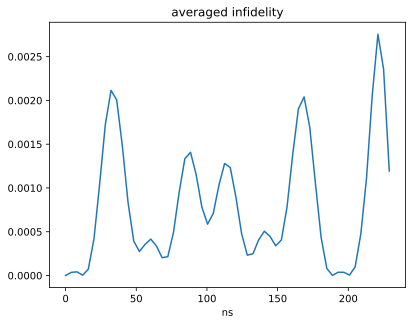

In [15]:


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*dm_ideal))

    return 1-sum(fid)/len(fid)
    


from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [states[idx] for states in two_level_states]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)


plt.plot(dm_tomo_results_list[0].times,infidelity)
plt.title("averaged infidelity")
plt.xlabel("ns")

In [16]:
# plt.plot(dm_tomo_results_list[0].times,phase,label = f'phase')

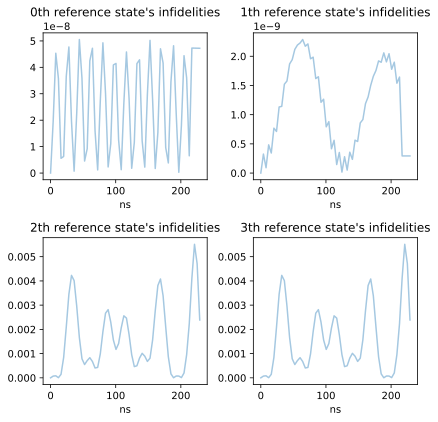

In [18]:
def calc_fidelity_with_phase(phase,dm,state_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    return 1-qutip.fidelity(dm, gate*state_ideal)

    

phases = []
infidelities = []
for i, states in enumerate(two_level_states):
    phases.append([])
    infidelities.append([])
    for idx in range(num_time_steps):
        dm = states[idx]
        def objective_function(params):
            return calc_fidelity_with_phase(params[0], dm, states_ideal[i])
        initial_phase = [0.0]
        opt_result = minimize(objective_function, initial_phase,method="COBYLA")
        phases[-1].append(opt_result.x)
        infidelities[-1].append(opt_result.fun)
# for i in range(4):
#     plt.plot(dm_tomo_results_list[0].times,infidelities[i],label = f'{i}th infidelities',alpha = 0.4)
# plt.title("infidelities")
# plt.xlabel("ns")
# plt.legend()

fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs = axs.flatten()
for i in range(4):
    axs[i].plot(dm_tomo_results_list[0].times, infidelities[i], label=f'{i}th infidelities', alpha=0.4)
    axs[i].set_title(f"{i}th reference state's infidelities")
    axs[i].set_xlabel("ns")
    # axs[i].legend()

plt.tight_layout()
plt.show()